# 01 – Keşifsel Veri Analizi (EDA)
Kripto Para Fiyat Yönü Sınıflandırması ve Getiri Tahmin Platformu

In [1]:
import sys
import os

# src/ klasörünü Python path'e ekle
sys.path.insert(0, os.path.abspath(".."))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# Görsel ayarlar
sns.set_theme(style="darkgrid")
plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["figure.dpi"] = 100

from src.load_data import load_filtered, filter_coin, get_all_tickers, RAW_DIR, PROCESSED_DIR

print("RAW_DIR     :", RAW_DIR)
print("PROCESSED_DIR:", PROCESSED_DIR)


RAW_DIR     : C:\Users\SPECIAL TEK\OneDrive\Masaüstü\ai-finance-prediction-platform-1\data\raw
PROCESSED_DIR: C:\Users\SPECIAL TEK\OneDrive\Masaüstü\ai-finance-prediction-platform-1\data\processed


In [2]:
# Veriyi yükle (kalite kontrollü)
df = load_filtered()

print(f"\nShape : {df.shape}")
print(f"Sütunlar: {df.columns.tolist()}")
print(f"Tarih aralığı: {df['date'].min().date()} → {df['date'].max().date()}")
print(f"Unique ticker: {df['ticker'].nunique()}")

df.head(10)


232599 satır, 101 ticker yüklendi
Kalite kontrolü geçti: 101 coin, 232599 satır

Shape : (232599, 6)
Sütunlar: ['ticker', 'date', 'open', 'high', 'low', 'close']
Tarih aralığı: 2010-07-17 → 2026-03-17
Unique ticker: 101


,ticker,date,open,high,low,close
0,BTC,2010-07-17,0.04951,0.04951,0.04951,0.04951
1,BTC,2010-07-18,0.04951,0.08585,0.04951,0.08584
2,BTC,2010-07-19,0.08584,0.09307,0.07723,0.08080
3,BTC,2010-07-20,0.08080,0.08181,0.07426,0.07474
4,BTC,2010-07-21,0.07474,0.07921,0.06634,0.07921
5,BTC,2010-07-22,0.07921,0.08181,0.05050,0.05050
6,BTC,2010-07-23,0.05050,0.06767,0.05050,0.06262
7,BTC,2010-07-24,0.06262,0.06262,0.05049,0.05454
8,BTC,2010-07-25,0.05454,0.05941,0.05050,0.05050
9,BTC,2010-07-26,0.05050,0.05600,0.05000,0.05600


Toplam ticker sayısı: 101
En çok satır: BTC (5674 satır)
En az satır : SYRUP (1034 satır)


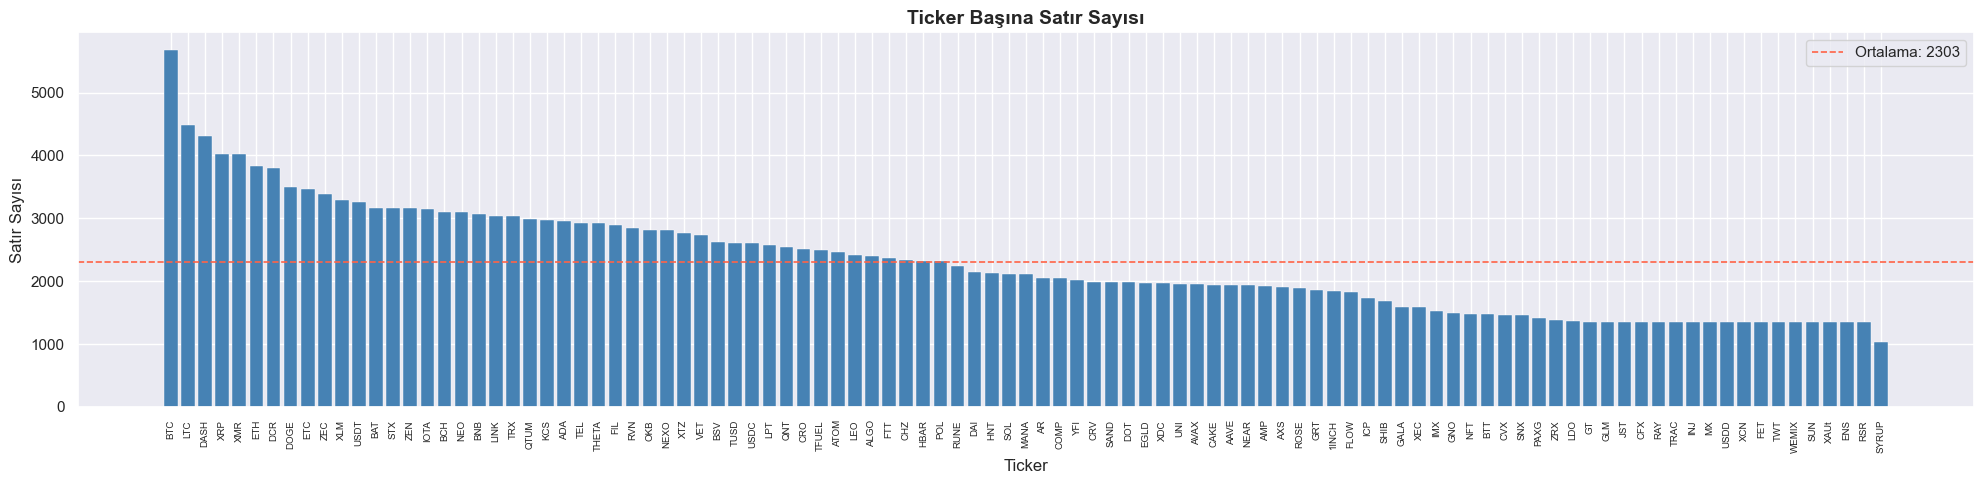

In [3]:
# Her ticker'ın kaç satırı var?
counts = df["ticker"].value_counts().sort_values(ascending=False)
tickers = get_all_tickers(df)

print(f"Toplam ticker sayısı: {len(tickers)}")
print(f"En çok satır: {counts.index[0]} ({counts.iloc[0]} satır)")
print(f"En az satır : {counts.index[-1]} ({counts.iloc[-1]} satır)")

fig, ax = plt.subplots(figsize=(20, 5))
ax.bar(counts.index, counts.values, color="steelblue", edgecolor="white", linewidth=0.3)
ax.set_title("Ticker Başına Satır Sayısı", fontsize=14, fontweight="bold")
ax.set_xlabel("Ticker")
ax.set_ylabel("Satır Sayısı")
ax.axhline(counts.mean(), color="tomato", linestyle="--", linewidth=1.2, label=f"Ortalama: {counts.mean():.0f}")
ax.tick_params(axis="x", rotation=90, labelsize=7)
ax.legend()
plt.tight_layout()
plt.show()


In [4]:
# Her coin için tarih aralığı ve satır sayısı özet tablosu
summary_rows = []
for ticker in tickers:
    coin = df[df["ticker"] == ticker]
    summary_rows.append({
        "ticker": ticker,
        "satir_sayisi": len(coin),
        "min_tarih": coin["date"].min().date(),
        "max_tarih": coin["date"].max().date(),
        "gun_arasi": (coin["date"].max() - coin["date"].min()).days,
    })

summary = pd.DataFrame(summary_rows).set_index("ticker").sort_values("satir_sayisi", ascending=False)

print("=== Coin Bazında Özet Tablo ===")
print(summary.to_string())


=== Coin Bazında Özet Tablo ===
        satir_sayisi   min_tarih   max_tarih  gun_arasi
ticker                                                 
BTC             5674  2010-07-17  2026-03-17       5722
LTC             4477  2013-10-24  2026-03-17       4527
DASH            4303  2014-04-18  2026-03-17       4351
XRP             4022  2015-01-21  2026-03-17       4073
XMR             4017  2015-01-29  2026-03-17       4065
ETH             3827  2015-08-07  2026-03-17       3875
DCR             3798  2015-09-05  2026-03-17       3846
DOGE            3498  2016-07-01  2026-03-17       3546
ETC             3472  2016-07-27  2026-03-17       3520
ZEC             3379  2016-10-28  2026-03-17       3427
XLM             3298  2017-01-17  2026-03-17       3346
USDT            3251  2017-03-05  2026-03-17       3299
BAT             3161  2017-06-01  2026-03-17       3211
ZEN             3158  2017-06-06  2026-03-17       3206
STX             3158  2015-05-13  2026-03-17       3961
IOTA            

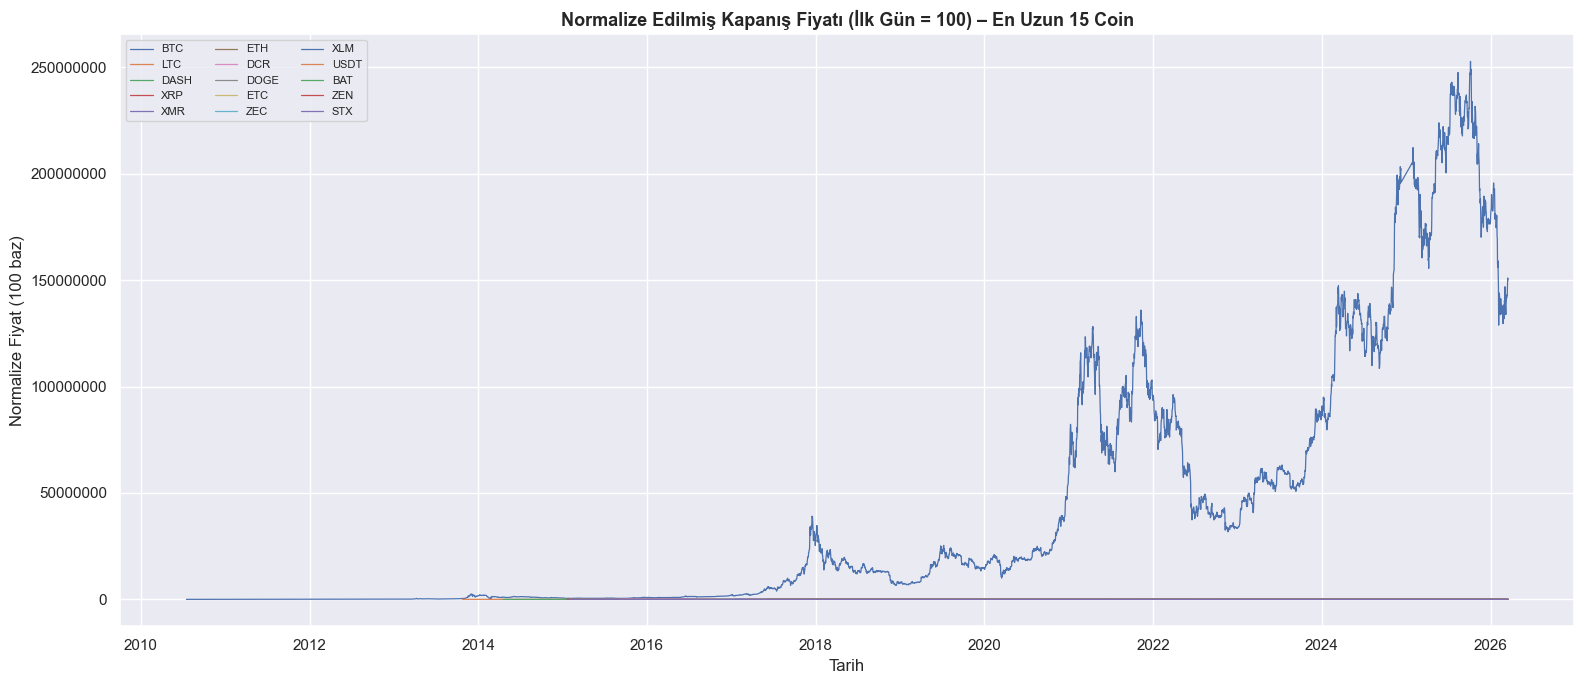

In [5]:
# Normalize edilmiş fiyat grafiği – ilk geçerli gün = 100 baz alınır
# 100 coin aynı anda çizilirse grafik okunaksız olur;
# en uzun geçmişe sahip ilk 15 coin seçilir (dinamik olarak)
top_tickers = summary.sort_values("satir_sayisi", ascending=False).head(15).index.tolist()

fig, ax = plt.subplots(figsize=(16, 7))
for ticker in top_tickers:
    coin = df[df["ticker"] == ticker].set_index("date")["close"].dropna()
    normalized = coin / coin.iloc[0] * 100
    ax.plot(normalized.index, normalized.values, linewidth=0.9, label=ticker)

ax.set_title("Normalize Edilmiş Kapanış Fiyatı (İlk Gün = 100) – En Uzun 15 Coin", fontsize=13, fontweight="bold")
ax.set_xlabel("Tarih")
ax.set_ylabel("Normalize Fiyat (100 baz)")
ax.legend(fontsize=8, ncol=3, loc="upper left")
ax.yaxis.set_major_formatter(mtick.FormatStrFormatter("%.0f"))
plt.tight_layout()
plt.show()


In [6]:
# Her coin için istatistiksel özet (close fiyatı üzerinden)
desc_rows = []
for ticker in tickers:
    coin = df[df["ticker"] == ticker]["close"].dropna()
    s = coin.describe()
    desc_rows.append({
        "ticker": ticker,
        "count": int(s["count"]),
        "mean":  round(s["mean"], 4),
        "std":   round(s["std"], 4),
        "min":   round(s["min"], 4),
        "25%":   round(s["25%"], 4),
        "50%":   round(s["50%"], 4),
        "75%":   round(s["75%"], 4),
        "max":   round(s["max"], 4),
    })

desc_df = pd.DataFrame(desc_rows).set_index("ticker")

# En yüksek ortalama fiyatlı 10 coin
print("=== Close Fiyatı İstatistikleri (ilk 10, ortalamaya göre sıralı) ===")
desc_df.sort_values("mean", ascending=False).head(10)


=== Close Fiyatı İstatistikleri (ilk 10, ortalamaya göre sıralı) ===


,count,mean,std,min,25%,50%,75%,max
ticker,,,,,,,,
BTC,5674,19737.8687,29331.4968,0.0495,257.7000,5863.6000,29159.6750,125173.0000
YFI,2013,13849.0611,12593.4267,1202.4000,5466.9600,7398.6500,21238.6000,82876.0000
XAUt,1353,2573.2811,911.0882,1630.7000,1913.9400,2177.5400,3205.0300,5433.8160
PAXG,1420,2544.3250,905.4564,1609.0000,1903.4700,2033.8900,3050.8775,5451.9460
ETH,3827,1328.5728,1312.1558,0.4200,174.4350,805.2300,2347.7900,4851.5400
BCH,3102,431.2352,356.1443,77.4100,229.5895,338.3035,525.9623,3715.9100
BNB,3064,285.8529,279.4708,0.6882,17.5375,256.1550,514.1652,1311.3070
GNO,1490,178.6126,90.2697,79.6909,113.6800,137.1482,214.2160,548.9100
AAVE,1936,166.5216,107.8511,27.7200,82.7811,125.6435,243.9260,630.0700


=== Sütun Bazında Eksik Değer Analizi ===
        eksik_sayi  eksik_yuzde
ticker           0          0.0
date             0          0.0
open             0          0.0
high             0          0.0
low              0          0.0
close            0          0.0


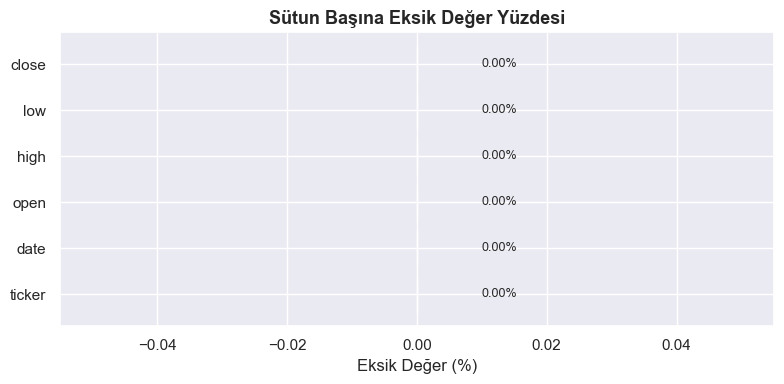

In [7]:
# Eksik değer analizi
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(4)
missing_df = pd.DataFrame({"eksik_sayi": missing, "eksik_yuzde": missing_pct})

print("=== Sütun Bazında Eksik Değer Analizi ===")
print(missing_df)

# Görselleştirme
fig, ax = plt.subplots(figsize=(8, 4))
colors = ["tomato" if v > 0 else "steelblue" for v in missing_pct.values]
ax.barh(missing_pct.index, missing_pct.values, color=colors)
ax.set_title("Sütun Başına Eksik Değer Yüzdesi", fontsize=13, fontweight="bold")
ax.set_xlabel("Eksik Değer (%)")
for i, (val, lbl) in enumerate(zip(missing_pct.values, missing_pct.index)):
    ax.text(val + 0.01, i, f"{val:.2f}%", va="center", fontsize=9)
plt.tight_layout()
plt.show()


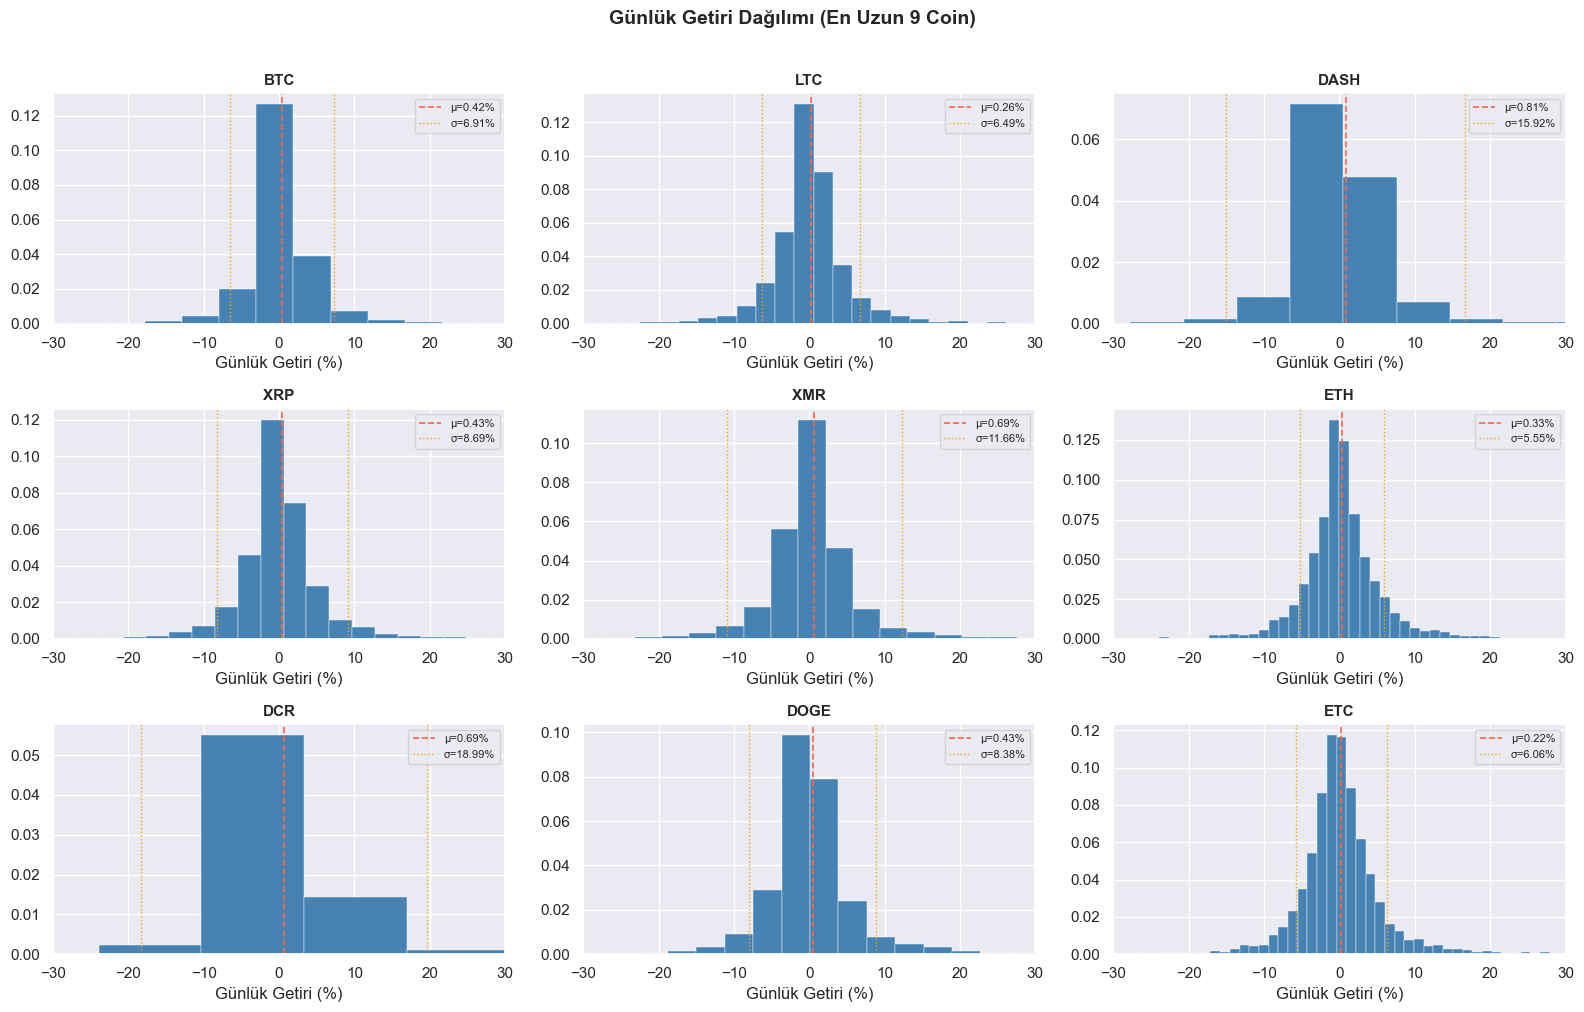

In [8]:
# Günlük getiri dağılımı – en uzun geçmişe sahip 9 coin (3x3 grid, dinamik)
top9 = summary.sort_values("satir_sayisi", ascending=False).head(9).index.tolist()

fig, axes = plt.subplots(3, 3, figsize=(16, 10))
axes = axes.flatten()

for i, ticker in enumerate(top9):
    coin = df[df["ticker"] == ticker].set_index("date")["close"].dropna()
    returns = coin.pct_change().dropna() * 100  # yüzde cinsinden

    mu, sigma = returns.mean(), returns.std()
    axes[i].hist(returns, bins=80, color="steelblue", edgecolor="white", linewidth=0.3, density=True)
    axes[i].axvline(mu, color="tomato", linestyle="--", linewidth=1.2, label=f"μ={mu:.2f}%")
    axes[i].axvline(mu + sigma, color="orange", linestyle=":", linewidth=1)
    axes[i].axvline(mu - sigma, color="orange", linestyle=":", linewidth=1, label=f"σ={sigma:.2f}%")
    axes[i].set_title(ticker, fontsize=11, fontweight="bold")
    axes[i].set_xlabel("Günlük Getiri (%)")
    axes[i].legend(fontsize=8)
    axes[i].set_xlim(-30, 30)

fig.suptitle("Günlük Getiri Dağılımı (En Uzun 9 Coin)", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()


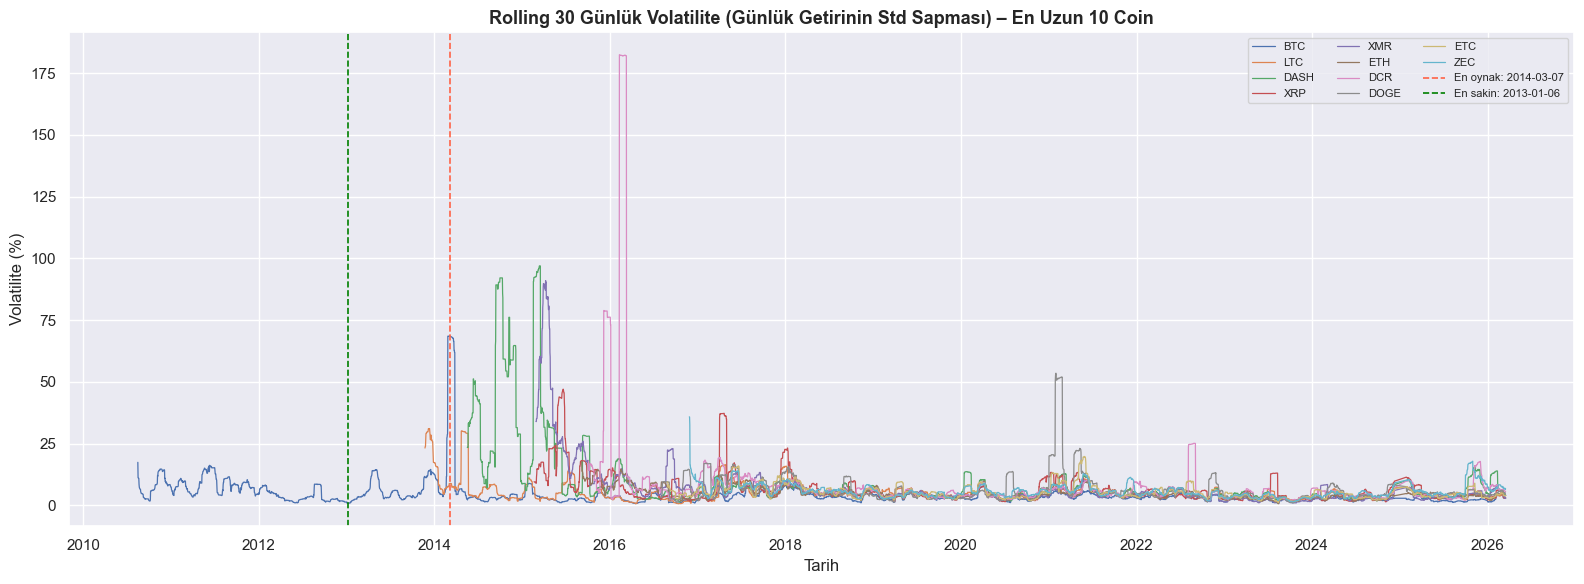

En oynak dönem : 2014-03-07
En sakin dönem : 2013-01-06


In [9]:
# Rolling 30 günlük volatilite karşılaştırması – en uzun 10 coin (dinamik)
top10 = summary.sort_values("satir_sayisi", ascending=False).head(10).index.tolist()

fig, ax = plt.subplots(figsize=(16, 6))

for ticker in top10:
    coin = df[df["ticker"] == ticker].set_index("date")["close"].dropna()
    returns = coin.pct_change()
    vol = returns.rolling(30).std() * 100  # yüzde cinsinden
    ax.plot(vol.index, vol.values, linewidth=0.9, label=ticker)

ax.set_title("Rolling 30 Günlük Volatilite (Günlük Getirinin Std Sapması) – En Uzun 10 Coin",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Tarih")
ax.set_ylabel("Volatilite (%)")
ax.legend(fontsize=8, ncol=2)

# En oynak ve en sakin dönem (tüm coinlerin ortalamasına göre)
avg_vol = pd.concat(
    [df[df["ticker"] == t].set_index("date")["close"].pct_change().rolling(30).std() for t in top10],
    axis=1
).mean(axis=1)

peak_date = avg_vol.idxmax()
calm_date = avg_vol.dropna().idxmin()
ax.axvline(peak_date, color="tomato", linestyle="--", linewidth=1.2, label=f"En oynak: {peak_date.date()}")
ax.axvline(calm_date, color="green", linestyle="--", linewidth=1.2, label=f"En sakin: {calm_date.date()}")
ax.legend(fontsize=8, ncol=3)

plt.tight_layout()
plt.show()
print(f"En oynak dönem : {peak_date.date()}")
print(f"En sakin dönem : {calm_date.date()}")


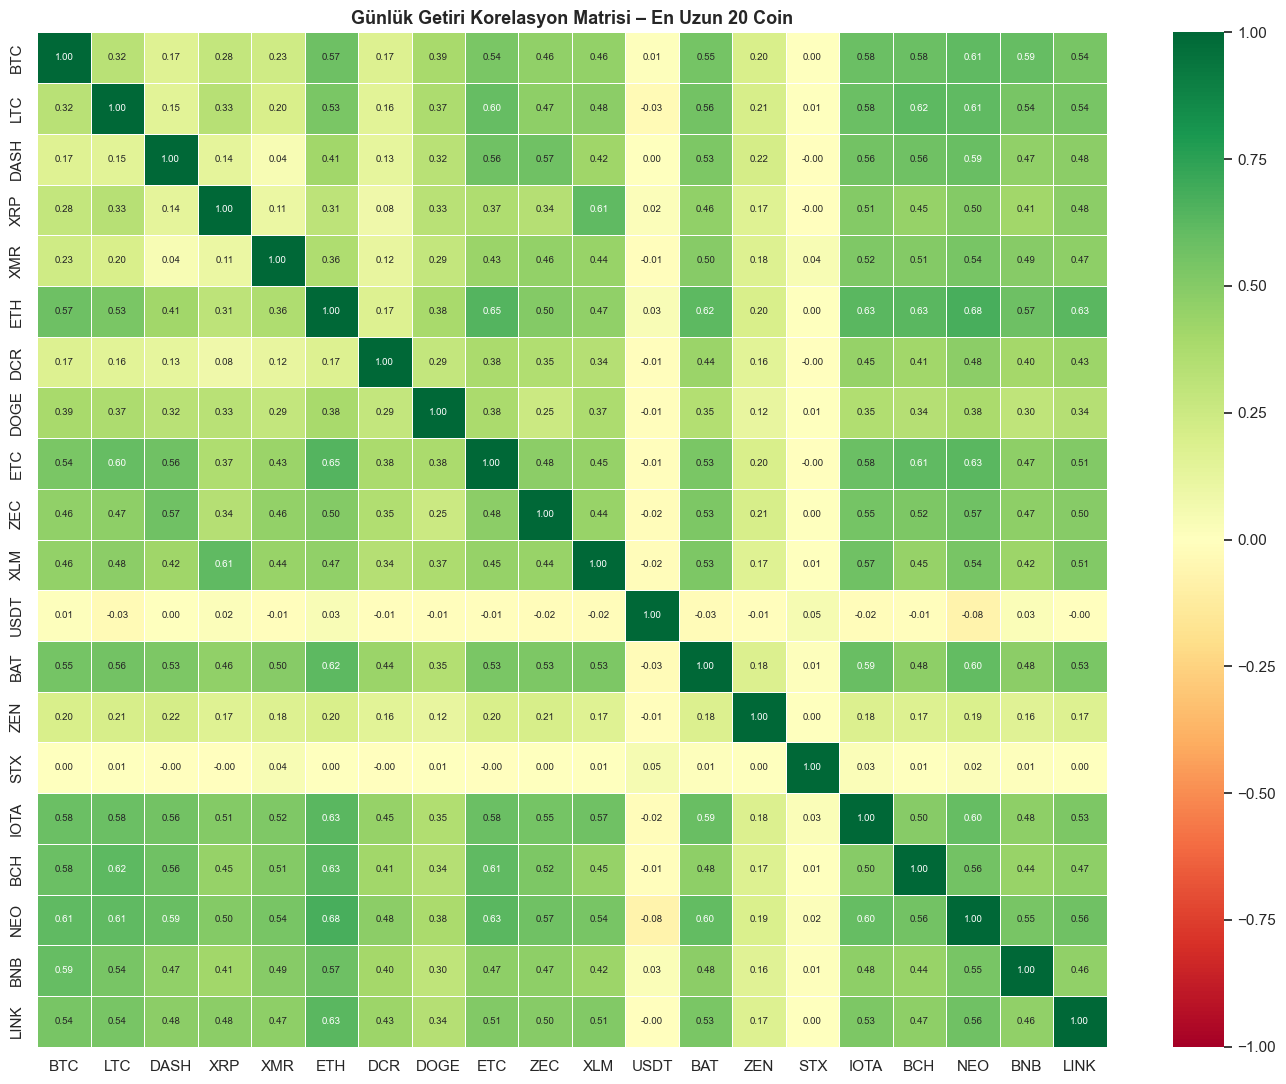

=== En yüksek korelasyonlu 5 çift ===
coin_1 coin_2  korelasyon
   NEO    ETH    0.676270
   ETC    ETH    0.645035
  IOTA    ETH    0.631614
   BCH    ETH    0.630396
  LINK    ETH    0.626833

=== En düşük korelasyonlu 5 çift ===
coin_1 coin_2  korelasyon
   NEO    BNB         NaN
   NEO   LINK         NaN
   BNB    BNB         NaN
   BNB   LINK         NaN
  LINK   LINK         NaN


In [10]:
# Coinler arası korelasyon matrisi – en uzun 20 coin (dinamik)
top20 = summary.sort_values("satir_sayisi", ascending=False).head(20).index.tolist()

# Her coin için günlük getiriyi ayrı sütun olarak al
returns_dict = {}
for ticker in top20:
    coin = df[df["ticker"] == ticker].set_index("date")["close"].dropna()
    returns_dict[ticker] = coin.pct_change()

returns_df = pd.DataFrame(returns_dict)

# Korelasyon matrisi
corr = returns_df.corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)  # üst üçgen boş bırakılır
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.4,
    ax=ax,
    annot_kws={"size": 7},
)
ax.set_title("Günlük Getiri Korelasyon Matrisi – En Uzun 20 Coin", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# En yüksek ve en düşük korelasyon çiftleri
corr_pairs = (
    corr.where(np.tril(np.ones(corr.shape), k=-1).astype(bool))
    .stack()
    .reset_index()
)
corr_pairs.columns = ["coin_1", "coin_2", "korelasyon"]
corr_pairs = corr_pairs.sort_values("korelasyon", ascending=False)

print("=== En yüksek korelasyonlu 5 çift ===")
print(corr_pairs.head(5).to_string(index=False))
print("\n=== En düşük korelasyonlu 5 çift ===")
print(corr_pairs.tail(5).to_string(index=False))
